JOLTS provides job openings by industry and region: https://fred.stlouisfed.org/release/tables?rid=192&eid=6614. Since we are interested in the stock of vacancies in relation to business formation, I pull the level of vacancies by industry using FredAPI below.  This recreates data tables for seasonally adjusted vacancies (https://fred.stlouisfed.org/release/tables?rid=192&eid=6615) and unadjusted vacancies (https://fred.stlouisfed.org/release/tables?rid=192&eid=6679).  Note that these two links are useful for visualizing the list of available sectors and their subsectors.  The data is exported to csv files: 'jolts_vacancies_industry_adjusted_levels.csv' for the seasonally adjusted series and 'jolts_vacancies_industry_unadjusted_levels.csv' for unadjusted series.

Seasonally adjusted data is available for 7 private sector industries plus the government sector, while unadjusted data is available for 10 private sector industries plus the government sector.  Specifically, the additional 3 sectors available for unadjusted data is 'Mining and Logging', 'Information', and 'Other Services'.  There are also subsectors available (e.g. durable/non-durable within Manufacturing), and additional subsectors available for unadjusted data.  

The sectors you mentioned in WhatsApp: construction, manufacturing, durables, nondurables, retail are all available as seasonally adjusted series.  

The JOLTS method for seasonal adjustment is a bit more complicated than removing outliers and applying a weighted moving average.  

From Gemini:  

> JOLTS has a unique problem: the number of hires minus the number of separations should roughly equal the total change in employment. However, because JOLTS is a smaller survey than the massive "Jobs Report" (CES), these numbers often drift apart. To fix this, the BLS uses an Alignment Method:

> 1. They seasonally adjust the JOLTS data.

> 2. They compare it to the seasonally adjusted net employment change from the larger CES survey.

> 3. They "align" the JOLTS hires and separations so they sum up to the more accurate CES totals.

> 4. They then "back-calculate" the factors to ensure everything remains mathematically consistent."

It's not totally clear why 3 sectors are not adjusted, something like Logging and Mining have perhaps too small sample size, but not totally sure about the other industries.

JOLTS ID naming convention: 
- 'JT' referes to JOLTS
- 'JTS' gives seasonally adjusted while 'JTU' gives unadjusted
- 'JTSXXXX' is industry code
- 'JTSXXXXJOL' is levels while 'JTSXXXXJOR' is rates

In [26]:
from fredapi import Fred
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
fred = Fred(api_key='9c70445138df124be4928605b7e08bd4')



In [59]:
load = True
if load == False:
    # Dictionary of industries for the seasonally adjusted level of vacancies
    industries_level = {
        'JTSJOL': 'Total Nonfarm',
        'JTS1000JOL': 'Total Private',
        'JTS2300JOL': 'Construction',
        'JTS3000JOL': 'Manufacturing',
        'JTS3200JOL': 'Durable Goods Manufacturing',
        'JTS3400JOL': 'Nondurable Goods Manufacturing',
        'JTS4000JOL': 'Trade, Transportation, and Utilities',
        'JTS4400JOL': 'Retail Trade',
        'JTS540099JOL': 'Professional and Business Services',
        'JTS6000JOL': 'Private Education and Health Services',
        'JTS6200JOL': 'Health Care and Social Assistance',
        'JTS7000JOL': 'Leisure and Hospitality',
        'JTS7100JOL': 'Arts, Entertainment, and Recreation',
        'JTS7200JOL': 'Accommodation and Food Services',
        'JTS9000JOL': 'Government',  
        'JTS9200JOL': 'State and Local',
    }
    
    data_list = []
    for series_id, name in industries_level.items():
        series_data = fred.get_series(series_id)
        series_data.name = name
        data_list.append(series_data)
    
    # Combine into one DataFrame
    df = pd.concat(data_list, axis=1)

    #Save to CSV
    df.to_csv('jolts_vacancies_industry_adjusted_levels.csv')
else:
    df = pd.read_csv('jolts_vacancies_industry_adjusted_levels.csv')

NameError: name 'pandas' is not defined

In [55]:
# List of industries for the unadjusted level of vacancies

industries_level_unadj = {
    'JTUJOL': 'Total Nonfarm',
    'JTU1000JOL': 'Total Private',
    'JTU110099JOL': 'Mining and Logging',
    'JTU2300JOL': 'Construction',
    'JTU3000JOL': 'Manufacturing',
    'JTU3200JOL': 'Durable Goods Manufacturing',
    'JTU3400JOL': 'Nondurable Goods Manufacturing',
    'JTU4000JOL': 'Trade, Transportation, and Utilities',
    'JTU4200JOL': 'Wholesale Trade',
    'JTS4400JOL': 'Retail Trade',
    'JTU4000JOL': 'Trade, Transportation, and Utilities ',
    'JTU5100JOL': 'Information',
    'JTU510099JOL': 'Financial Activities',
    'JTU5300JOL': 'Real Estate and Rental and Leasing',
    'JTU540099JOL': 'Professional and Business Services',
    'JTU6000JOL': 'Private Education and Health Services',
    'JTU6100JOL': 'Private Educational Services',
    'JTU6200JOL': 'Health Care and Social Assistance',
    'JTU7000JOL': 'Leisure and Hospitality',
    'JTU7100JOL': 'Arts, Entertainment, and Recreation',
    'JTU7200JOL': 'Accommodation and Food Services',
    'JTU8100JOL': 'Other Services ',
    'JTU9000JOL': 'Government', 
    'JTU9100JOL': 'Federal', 
    'JTU9200JOL': 'State and Local',
}

data_list = []
for series_id, name in industries_level.items():
    series_data = fred.get_series(series_id)
    series_data.name = name
    data_list.append(series_data)

# Combine into one DataFrame
df = pd.concat(data_list, axis=1)

# Save to CSV
df.to_csv('jolts_vacancies_industry_unadjusted_levels.csv')

In [60]:
display(df.shape, df.columns)
df.head()

(301, 16)

Index(['Total Nonfarm', 'Total Private', 'Construction', 'Manufacturing',
       'Durable Goods Manufacturing', 'Nondurable Goods Manufacturing',
       'Trade, Transportation, and Utilities', 'Retail Trade',
       'Professional and Business Services',
       'Private Education and Health Services',
       'Health Care and Social Assistance', 'Leisure and Hospitality',
       'Arts, Entertainment, and Recreation',
       'Accommodation and Food Services', 'Government', 'State and Local'],
      dtype='object')

,Total Nonfarm,Total Private,Construction,Manufacturing,Durable Goods Manufacturing,Nondurable Goods Manufacturing,"Trade, Transportation, and Utilities",Retail Trade,Professional and Business Services,Private Education and Health Services,Health Care and Social Assistance,Leisure and Hospitality,"Arts, Entertainment, and Recreation",Accommodation and Food Services,Government,State and Local
2000-12-01,5088.0,4541.0,233.0,425.0,301.0,124.0,784.0,502.0,871.0,919.0,864.0,566.0,42.0,525.0,548.0,481.0
2001-01-01,5234.0,4752.0,241.0,445.0,304.0,141.0,955.0,533.0,888.0,842.0,801.0,654.0,57.0,597.0,482.0,413.0
2001-02-01,5097.0,4619.0,253.0,420.0,281.0,139.0,962.0,586.0,1032.0,808.0,751.0,601.0,43.0,558.0,479.0,416.0
2001-03-01,4762.0,4316.0,188.0,436.0,249.0,187.0,687.0,431.0,901.0,818.0,761.0,695.0,126.0,568.0,445.0,388.0
2001-04-01,4615.0,4125.0,226.0,354.0,236.0,118.0,848.0,502.0,834.0,708.0,645.0,582.0,49.0,533.0,490.0,425.0


In [61]:
industry_gr = ["Nondurable Goods Manufacturing", 
            "Durable Goods Manufacturing",
            "Construction",
            "Trade, Transportation, and Utilities",
            "Retail Trade",
            "Professional and Business Services"]

In [62]:
ind_means = df[industry_gr].apply(np.mean, axis=0)
ind_means.sort_values(ascending=False, inplace=True)
print(ind_means)

Professional and Business Services      1014.598007
Trade, Transportation, and Utilities     945.873754
Retail Trade                             568.521595
Durable Goods Manufacturing              225.202658
Construction                             192.860465
Nondurable Goods Manufacturing           140.897010
dtype: float64


In [63]:
type(df["Retail Trade"])

pandas.core.series.Series

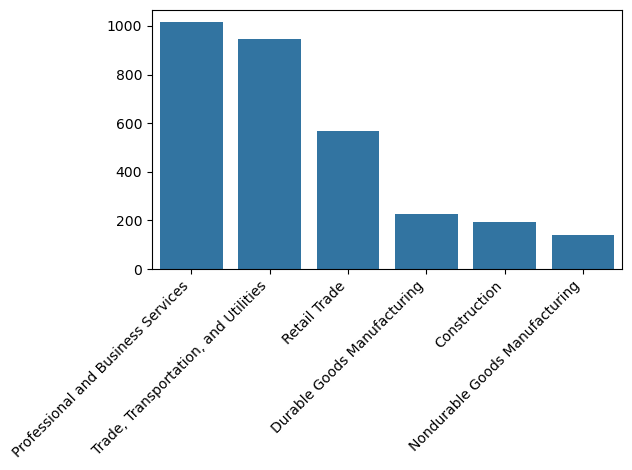

In [64]:

fig, ax = plt.subplots()
sns.barplot(data=ind_means, ax=ax)
plt.xticks(rotation=45, ha="right") # rotate and align labels
plt.tight_layout()
plt.show()

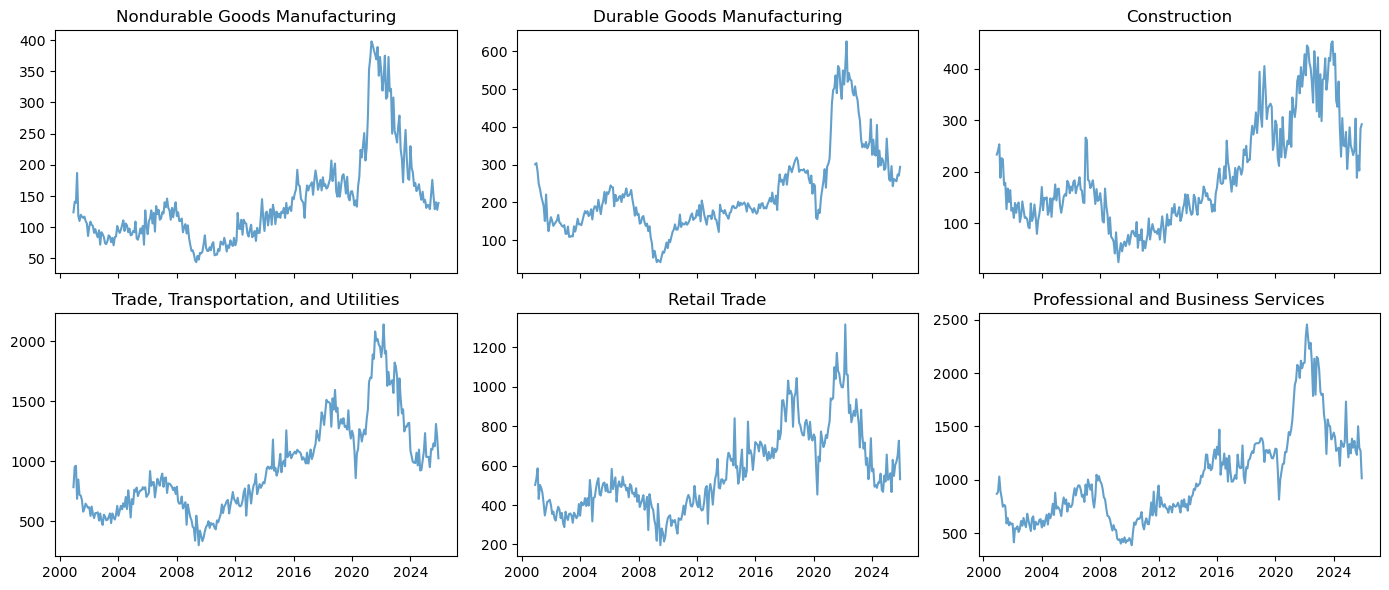

In [69]:
# Time series plots 
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(14, 6), 
                       sharex=True, sharey=False)
axes_flat = axes.ravel()
for i, col in enumerate(industry_gr):
    ax = axes_flat[i] # flatten the axes
    ax.plot(df.index, df[col], linestyle='-', alpha=0.7)
    ax.set_title(col)
plt.tight_layout()

In [66]:
df

,Total Nonfarm,Total Private,Construction,Manufacturing,Durable Goods Manufacturing,Nondurable Goods Manufacturing,"Trade, Transportation, and Utilities",Retail Trade,Professional and Business Services,Private Education and Health Services,Health Care and Social Assistance,Leisure and Hospitality,"Arts, Entertainment, and Recreation",Accommodation and Food Services,Government,State and Local
2000-12-01,5088.0,4541.0,233.0,425.0,301.0,124.0,784.0,502.0,871.0,919.0,864.0,566.0,42.0,525.0,548.0,481.0
2001-01-01,5234.0,4752.0,241.0,445.0,304.0,141.0,955.0,533.0,888.0,842.0,801.0,654.0,57.0,597.0,482.0,413.0
2001-02-01,5097.0,4619.0,253.0,420.0,281.0,139.0,962.0,586.0,1032.0,808.0,751.0,601.0,43.0,558.0,479.0,416.0
2001-03-01,4762.0,4316.0,188.0,436.0,249.0,187.0,687.0,431.0,901.0,818.0,761.0,695.0,126.0,568.0,445.0,388.0
2001-04-01,4615.0,4125.0,226.0,354.0,236.0,118.0,848.0,502.0,834.0,708.0,645.0,582.0,49.0,533.0,490.0,425.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-08-01,7227.0,6457.0,188.0,409.0,259.0,150.0,1149.0,603.0,1235.0,1523.0,1378.0,1092.0,106.0,986.0,770.0,693.0
2025-09-01,7658.0,6871.0,231.0,385.0,256.0,129.0,1124.0,620.0,1502.0,1512.0,1375.0,1181.0,162.0,1019.0,787.0,673.0
2025-10-01,7449.0,6665.0,202.0,414.0,274.0,140.0,1310.0,651.0,1300.0,1531.0,1401.0,1155.0,170.0,985.0,784.0,698.0
2025-11-01,6928.0,6227.0,284.0,399.0,271.0,128.0,1196.0,726.0,1273.0,1464.0,1341.0,884.0,160.0,724.0,701.0,598.0
